## 1. What this notebook computes

The field equation of dirac16complex (and of dirac16complex00, which has the same
equation) in the author's 4 + 4 dimensional primordial universe has FOUR time-like
directions: the time $x_4$ and the three extra times $x_5, x_6, x_7$. This notebook
shows what that means for the waves of the field. It

- reads the author's sixteen-by-sixteen gamma matrices from the Revision record and
  checks the 64 Clifford relations;
- builds the *mode matrix* $h_k$ of a plane wave with frozen coefficients and proves
  exactly (with sympy) that $h_k^2 = E^2\,I_{16}$ with
  $E^2 = m^2 + k_1^2 + k_2^2 + k_3^2 + k_8^2 - k_5^2 - k_6^2 - k_7^2$;
- shows that a wave with a large momentum $K$ along an extra time does not oscillate
  but GROWS like $e^{\kappa x_4}$ with the growth rate
  $\kappa = \sqrt{K^2 - m^2 - k_1^2 - k_2^2 - k_3^2 - k_8^2}$, and that $\kappa$ has
  no upper bound;
- solves the wave equation in time in two independent ways (an exact formula and a
  step-by-step numerical method) and compares them;
- shows that therefore a tiny change of the starting values can make an arbitrarily
  large change later: the initial-value problem is NOT well posed in the sense of
  Hadamard (for starting values that depend on the extra times; exactly in flat
  4 + 4 space, and with frozen coefficients in the author's metric);
- checks that the Krein form $u^\dagger B u$ stays constant while the ordinary size
  $u^\dagger u$ grows, and that the growing waves have Krein form zero;
- shows that without extra-time momentum (the *good sector*) every frequency is real.

Every exact statement reproduces a check of a Revision record, named in the PASS
line. The notebook draws six teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 08a (Growth rates of the extra-time waves and Hadamard ill-posedness) is the
file `Revision/textbook/notebooks/08a_growth_rates.ipynb` of the repository Dirac_claude.
It builds the 16 x 16 mode matrix of a plane wave of the field equation with frozen
coefficients from the author's gamma matrices, proves exactly that its square is E^2
times the unit matrix, computes the growth rate of the waves that move along an extra
time, shows that this rate has no upper bound (so, in flat 4 + 4 space and with frozen
coefficients, the initial-value problem is not well posed in the sense of Hadamard),
checks that the Krein form is conserved while the ordinary norm grows, and draws six
teaching plots. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy,
sympy and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 08a_growth_rates.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 08a_growth_rates.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
08a_growth_rates.ipynb` (in the same folder, without running the cells again) to read the
printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/08a.captions.json`
- `Revision/textbook/figures/08a_1_growth_rate_vs_momentum.png`
- `Revision/textbook/figures/08a_2_growth_map.png`
- `Revision/textbook/figures/08a_3_norm_in_time.png`
- `Revision/textbook/figures/08a_4_hadamard_ratio.png`
- `Revision/textbook/figures/08a_5_krein_norm.png`
- `Revision/textbook/figures/08a_6_eigenvalue_paths.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the figure file 08a_6_eigenvalue_paths.png exists
    ALL 30 CHECKS PASSED (notebook 08a)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/08a_growth_rates.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- FileNotFoundError naming Revision/algebra/gammas.json: the notebook reads this Revision
  record of the repository. Check that the folder Revision/algebra of your copy of the
  repository contains the file gammas.json (clone the repository again if it does not)
  and that you opened the notebook from its folder Revision/textbook/notebooks.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 08a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 08a (Growth rates of the extra-time waves and Hadamard ill-posedness) is the
# file Revision/textbook/notebooks/08a_growth_rates.ipynb of the repository Dirac_claude.
# It builds the 16 x 16 mode matrix of a plane wave of the field equation with frozen
# coefficients from the author's gamma matrices, proves exactly that its square is E^2
# times the unit matrix, computes the growth rate of the waves that move along an extra
# time, shows that this rate has no upper bound (so, in flat 4 + 4 space and with frozen
# coefficients, the initial-value problem is not well posed in the sense of Hadamard),
# checks that the Krein form is conserved while the ordinary norm grows, and draws six
# teaching plots. It needs a computer with Windows 11, macOS or Linux, an internet
# connection for the installation, the program Git, and Python 3.12 or newer (the
# notebooks were built with Python 3.14.5) with these packages at exactly these versions:
# numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat
# 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself
# imports numpy, sympy and matplotlib; the other packages run Jupyter, the program that
# shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 08a_growth_rates.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 08a_growth_rates.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 08a_growth_rates.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/08a.captions.json
# - Revision/textbook/figures/08a_1_growth_rate_vs_momentum.png
# - Revision/textbook/figures/08a_2_growth_map.png
# - Revision/textbook/figures/08a_3_norm_in_time.png
# - Revision/textbook/figures/08a_4_hadamard_ratio.png
# - Revision/textbook/figures/08a_5_krein_norm.png
# - Revision/textbook/figures/08a_6_eigenvalue_paths.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the figure file 08a_6_eigenvalue_paths.png exists
#     ALL 30 CHECKS PASSED (notebook 08a)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/08a_growth_rates.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - FileNotFoundError naming Revision/algebra/gammas.json: the notebook reads this
#   Revision record of the repository. Check that the folder Revision/algebra of your
#   copy of the repository contains the file gammas.json (clone the repository again if
#   it does not) and that you opened the notebook from its folder
#   Revision/textbook/notebooks.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "08a"  # this notebook: chapter 08, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 08a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** $x_1, \dots, x_8$ (the author's names): $x_1, x_2, x_3$ ordinary
  space (it inflates); $x_4$ the time; $x_5, x_6, x_7$ the three *extra times*,
  time-like directions that DEFLATE exponentially (their lengths carry the factor
  $e^{-a_4}\sin^{1/6} z$ with $a_4$ increasing); $x_8$ the hidden space direction,
  $z = 6 H x_8$ between $0$ and $\pi/2$.
- **Gamma matrices** $\gamma^{(1)}, \dots, \gamma^{(8)}$: sixteen-by-sixteen matrices
  of the numbers $0, 1, -1$ with $\gamma^{(a)}\gamma^{(b)} + \gamma^{(b)}\gamma^{(a)}
  = 2\eta^{ab} I_{16}$ (the *Clifford relation*), $\eta = \mathrm{diag}(+1, +1, +1,
  -1, -1, -1, -1, +1)$: a gamma squares to $+1$ for a space-like direction and to
  $-1$ for a time-like one. $I_{16}$ is the unit matrix.
- **Plane wave**: a field of the form $\Psi = u\, e^{i(k_1 x_1 + \dots + k_8 x_8)
  - i E x_4}$ (no $k_4$ term) with a constant column $u$ of 16 complex numbers.
  $k_a$ is the *wave number* or *momentum* along $x_a$ (radians of phase per unit
  length) and $E$ the *frequency*.
- **Frozen coefficients**: in a curved space the factors in front of the derivatives
  change from point to point and in time; near one point and for a short time one
  replaces them by their values at that point. The momenta measured with these
  factors are the *frame momenta* $k_a$. This is a device of the analysis near one
  point (labelled MODEL); it does NOT say that the extra times stop deflating: in
  the author's metric they always deflate exponentially, and Notebook 08b follows a
  wave along the deflating history.
- **Mode matrix** $h_k$: the $16 \times 16$ complex matrix with $E u = h_k u$.
- **Eigenvalue, eigenvector**: $E$ and $u \neq 0$ with $h_k u = E u$; the
  *eigenspace* of $E$ is the set of all such $u$; its *dimension* is the number of
  independent ones.
- **Oscillation and growth**: $e^{-iEx_4}$ oscillates (its size stays 1) when $E$
  is real; when $E = \pm i\kappa$ with $\kappa > 0$ it is $e^{\pm\kappa x_4}$, which
  grows or decays exponentially. $\kappa$ is the **growth rate**.
- **Conjugate transpose** $M^\dagger$: transpose the matrix and replace every entry
  by its complex conjugate. **Hermitian**: $M^\dagger = M$; a Hermitian matrix has
  only real eigenvalues.
- **Hilbert norm** $u^\dagger u = |u_1|^2 + \dots + |u_{16}|^2$ (the ordinary size
  squared) and **Krein form** $u^\dagger B u$ with the matrix $B = -iC\gamma^{(4)}$ of
  the record ($B^\dagger = B$, $B^2 = 1$, eight eigenvalues $+1$ and eight $-1$); the
  Krein form can be negative or zero for $u \neq 0$.
- **Good sector**: the fields that do not depend on $x_5, x_6, x_7$ ($k_5 = k_6 =
  k_7 = 0$).
- **Initial-value (Cauchy) problem**: find the field at later times $x_4$ from its
  values at $x_4 = 0$ (the *data*). It is **well posed in the sense of Hadamard** if
  a solution exists, is unique, and depends *continuously* on the data: a small
  enough change of the data changes the solution at a later time only a little.
- **Sobolev norm of order $s$**: a way to measure the size of data that also counts
  how fast they wiggle; for one wave of momentum $K$ and amplitude $\epsilon$ it is
  $\epsilon\,(1 + K^2)^{s/2}$. Larger $s$ punishes wiggly data more.
- **RK4**: the classical fourth-order Runge-Kutta method, a step-by-step numerical
  method for equations $du/dt = F(t, u)$.

## 4. The physical and mathematical situation

The field equation (with $U = 0$) in the author's metric, in the diagonal frame, is

$$e^{-a_4}\sin^{-1/6}z\,\gamma^{(i)}\partial_i\Psi + \gamma^{(4)}\partial_4\Psi
+ e^{a_4}\sin^{-1/6}z\,\gamma^{(t)}\partial_t\Psi + \tan z\,\gamma^{(8)}\partial_8\Psi
+ 3H\gamma^{(8)}\Psi = m\Psi$$

(sums over $i = 1, 2, 3$ and $t = 5, 6, 7$). The term $3H\gamma^{(8)}\Psi$ disappears
exactly in the variables $\chi = \sin^{1/2}z\,\Psi$ (Revision check
`rescaling_removes_the_connection_term`). With frozen coefficients the factors
$e^{\mp a_4}\sin^{-1/6}z$ and $\tan z$ become constants and are absorbed into the
frame momenta $k_a$; in flat 4 + 4 space they are exactly 1. (Freezing them is a
local MODEL: along the history $a_4(x_4)$ the extra-time factor $e^{a_4}$ keeps
growing, so the frame momentum of a given wave along an extra time keeps growing
too; Notebook 08b computes that.) So for a plane wave the equation reads, line by
line:

1. $\gamma^{(4)}(-iE)u + \sum_{a \neq 4} i k_a \gamma^{(a)} u = m u$, because
   $\partial_4$ gives the factor $-iE$ and $\partial_a$ the factor $i k_a$.
2. Multiply from the left by $\gamma^{(4)}$ and use $(\gamma^{(4)})^2 = -1$:
   $iE u + i\sum_a k_a \gamma^{(4)}\gamma^{(a)} u = m\gamma^{(4)} u$.
3. Multiply by $-i$ and solve for $E u$:
   $E u = h_k u$ with $h_k = -i m\gamma^{(4)} - \gamma^{(4)}\sum_{a \neq 4}
   k_a\gamma^{(a)}$.

Squaring $h_k$ with the Clifford relation gives $h_k^2 = E^2 I_{16}$ with
$E^2 = m^2 + k_1^2 + k_2^2 + k_3^2 + k_8^2 - k_5^2 - k_6^2 - k_7^2$: the
extra-time momenta enter with a MINUS sign, because the extra times are time-like.
When $k_5^2 + k_6^2 + k_7^2 > m^2 + k_1^2 + k_2^2 + k_3^2 + k_8^2$, $E^2 < 0$, the
frequencies are $\pm i\kappa$, and half of the waves grow like $e^{\kappa x_4}$.

Units: $m$, every $k_a$ and $\kappa$ are measured in the same unit (an inverse
length) and $x_4$ in its inverse; every number below is a pure number in this unit.

## 5. The author's gamma matrices

The next cell first defines two helpers for the checks that reproduce a Revision
record. `record_says(report, name, ...)` opens the report (a JSON file with a list
of checks, each with a name, a verdict and a detail text) and is true when the
check `name` is there with the verdict pass and its detail text contains every
further piece of text given (for example a number that this notebook computes).
`check_record(condition, title, report, name, ...)` is the helper `check` for such
a result: it passes only if the notebook's own computation (`condition`) is right
AND the record says the same. Then the cell reads the record
`Revision/algebra/gammas.json`, turns the eight gamma matrices and the matrix $B$
into numpy arrays and checks the Clifford relation for all $8 \times 8 = 64$
ordered pairs $(a, b)$ with exact integer arithmetic. In Python lists count from 0,
so $\gamma^{(x_1)}$ is `GAMMA[0]` and $\gamma^{(x_4)}$ is `GAMMA[3]`. Last, it
checks $(\gamma^{(x_4)})^2 = -I_{16}$: multiplying the field equation by
$-\gamma^{(x_4)}$ solves it for $\partial_4\Psi$, so the field equation says how the
field changes in the time $x_4$ (the slices $x_4 = $ const are *non-characteristic*).
Section 12 shows that this does NOT make the initial-value problem well posed.

In [2]:
import numpy as np  # arrays of numbers, matrices, linear algebra
import sympy as sp  # exact algebra with symbols

REPORTS = {}  # report file -> {check name: (verdict, detail)}, each read once


def record_says(report_file, check_name, *pieces):
    """True when the Revision report records the check check_name with the verdict
    pass and its detail text contains every given piece of text."""
    if report_file not in REPORTS:  # read the report the first time it is needed
        data = json.loads(repository_file(report_file).read_text(encoding="utf-8"))
        REPORTS[report_file] = {entry["name"]: (entry["verdict"].lower(),
                                                entry["detail"])
                                for entry in data["checks"]}
    verdict, detail = REPORTS[report_file][check_name]
    return verdict == "pass" and all(piece in detail for piece in pieces)


def check_record(condition, title, report_file, check_name, *pieces):
    """check() for a result that reproduces the Revision check check_name: it passes
    only if condition is true AND the report records check_name as passed, with
    every piece of text (values computed here) in its detail."""
    on_record = record_says(report_file, check_name, *pieces)
    check(condition and on_record, title,
          record=f"{report_file}, check {check_name}")


gammas_record = json.loads(
    repository_file("Revision/algebra/gammas.json").read_text(encoding="utf-8"))
# The record stores every matrix as a list of rows of whole numbers.
GAMMA = [np.array(rows, dtype=int) for rows in gammas_record["gamma"]]
ETA = gammas_record["eta"]  # [1, 1, 1, -1, -1, -1, -1, 1] in the order x1 ... x8
# B = -i C gamma^(x4) is stored as its real part and its imaginary part.
B = np.array(gammas_record["B"]["re"]) + 1j * np.array(gammas_record["B"]["im"])
I16 = np.eye(16, dtype=int)  # the 16 x 16 unit matrix
say(f"eta = {ETA}; each gamma is a {GAMMA[0].shape[0]} x {GAMMA[0].shape[1]} matrix")
clifford_ok = all(
    np.array_equal(GAMMA[a] @ GAMMA[b] + GAMMA[b] @ GAMMA[a],
                   2 * ETA[a] * (a == b) * I16)  # (a == b) is 1 or 0
    for a in range(8) for b in range(8))
check_record(clifford_ok, "the 64 Clifford relations {gamma^a, gamma^b} = 2 eta^ab I16",
             "Revision/algebra/reports/python-algebra.json", "clifford_relation",
             "for all 64 ordered pairs")
check(np.allclose(B, B.conj().T) and np.allclose(B @ B, np.eye(16)),
      "B is Hermitian and B^2 = 1")
# (gamma^(x4))^2 = -1: the field equation can be solved for d4 Psi (multiply it by
# -gamma^(x4)), so the slices x4 = const are non-characteristic.
check_record(np.array_equal(GAMMA[3] @ GAMMA[3], -I16),
             "(gamma^(x4))^2 = -1: the slices x4 = const are non-characteristic",
             "Revision/theory/reports/wolfram-field-theory.json", "evolution_form_G",
             "the slices x4 = const are non-characteristic")

eta = [1, 1, 1, -1, -1, -1, -1, 1]; each gamma is a 16 x 16 matrix
PASS the 64 Clifford relations {gamma^a, gamma^b} = 2 eta^ab I16
     reproduces Revision/algebra/reports/python-algebra.json, check clifford_relation
PASS B is Hermitian and B^2 = 1
PASS (gamma^(x4))^2 = -1: the slices x4 = const are non-characteristic
     reproduces Revision/theory/reports/wolfram-field-theory.json, check evolution_form_G


## 6. The mode matrix and its square, exactly

The next cell builds $h_k = -i m\gamma^{(4)} - \gamma^{(4)}\sum_{a \neq 4}
k_a\gamma^{(a)}$ with sympy, where $m$ and the seven momenta are symbols (letters
that stand for any real numbers), and checks three exact statements: $h_k^2 = E^2
I_{16}$ with the $E^2$ of section 4; the trace of $h_k$ (the sum of its diagonal) is
0, so its eigenvalues $+E$ and $-E$ occur equally often (8 times each); and
$B h_k = h_k^\dagger B$, which says that $h_k$ is *self-adjoint for the Krein form*
(section 13 uses it). sympy prints a power with two stars: `k1**2` means $k_1^2$.
The Revision record was checked by two independent programs, one in Python (sympy)
and one in the Wolfram language; the cell checks that the reports of BOTH contain
exactly the $E^2$ computed here.

In [3]:
m = sp.Symbol("m", real=True)  # the mass
k = {a: sp.Symbol(f"k{a}", real=True) for a in (1, 2, 3, 5, 6, 7, 8)}  # momenta
G = [sp.Matrix(rows) for rows in gammas_record["gamma"]]  # the gammas, exact
B_exact = sp.I * sp.Matrix(gammas_record["B"]["im"])  # B is purely imaginary
g4 = G[3]  # gamma^(x4)
momentum_part = sp.zeros(16, 16)
for a, k_a in k.items():  # a runs over 1, 2, 3, 5, 6, 7, 8
    momentum_part += k_a * g4 * G[a - 1]  # k_a gamma^(x4) gamma^(xa)
h = -sp.I * m * g4 - momentum_part  # the mode matrix h_k
E2 = m**2 + k[1]**2 + k[2]**2 + k[3]**2 + k[8]**2 - k[5]**2 - k[6]**2 - k[7]**2
say(f"E^2 = {E2}")
square_minus_E2 = (h * h - E2 * sp.eye(16)).applyfunc(sp.expand)
square_ok = square_minus_E2 == sp.zeros(16, 16)
# The two independent Revision verifiers print E^2 in their own notations: sympy
# writes powers with **, the Wolfram verifier with ^. Both texts must hold this E^2.
E2_sympy_text = sp.sstr(E2)  # "k1**2 + k2**2 + ... + m**2"
E2_wolfram_text = E2_sympy_text.replace("**", "^")  # "k1^2 + k2^2 + ... + m^2"
check_record(square_ok,
             "h_k^2 = E^2 I16, E^2 = m^2 + k1^2 + k2^2 + k3^2 + k8^2 - k5^2 - k6^2 "
             "- k7^2", "Revision/theory/reports/python-scope.json",
             "extra_time_growth_rates_unbounded", f"h_k^2 = ({E2_sympy_text}) I16")
check_record(square_ok, "the same E^2 in the independent Wolfram verifier",
             "Revision/theory/reports/wolfram-scope.json",
             "extra_time_growth_rates_unbounded", f"h_k^2 = ({E2_wolfram_text}) I16")
check(sp.expand(h.trace()) == 0, "the trace of h_k is 0 (eigenvalues +E, -E, 8 each)")
krein = (B_exact * h - h.H * B_exact).applyfunc(sp.expand)  # .H: conjugate transpose
check_record(krein == sp.zeros(16, 16), "B h_k = h_k^dagger B (Krein self-adjoint)",
             "Revision/theory/reports/python-field-theory.json",
             "mode_hamiltonian_B_selfadjoint_dispersion", "B h = h^dagger B")

E^2 = k1**2 + k2**2 + k3**2 - k5**2 - k6**2 - k7**2 + k8**2 + m**2
PASS h_k^2 = E^2 I16, E^2 = m^2 + k1^2 + k2^2 + k3^2 + k8^2 - k5^2 - k6^2 - k7^2
     reproduces Revision/theory/reports/python-scope.json, check
    extra_time_growth_rates_unbounded
PASS the same E^2 in the independent Wolfram verifier
     reproduces Revision/theory/reports/wolfram-scope.json, check
    extra_time_growth_rates_unbounded
PASS the trace of h_k is 0 (eigenvalues +E, -E, 8 each)
PASS B h_k = h_k^dagger B (Krein self-adjoint)
     reproduces Revision/theory/reports/python-field-theory.json, check
    mode_hamiltonian_B_selfadjoint_dispersion


## 7. When is the mode matrix Hermitian?

Split $h_k$ into its Hermitian part $(h_k + h_k^\dagger)/2$ and its anti-Hermitian
part $(h_k - h_k^\dagger)/2$. The next cell shows that the anti-Hermitian part is
exactly $-\gamma^{(4)}(k_5\gamma^{(5)} + k_6\gamma^{(6)} + k_7\gamma^{(7)})$, the
extra-time part, and that its square is $-(k_5^2 + k_6^2 + k_7^2) I_{16}$. A matrix
whose square is a negative number times $I_{16}$ is zero only when that number is
zero: $h_k$ is Hermitian exactly when there is no extra-time momentum.

In [4]:
anti = ((h - h.H) / 2).applyfunc(sp.expand)  # the anti-Hermitian part of h_k
extra_time_part = -(k[5] * g4 * G[4] + k[6] * g4 * G[5] + k[7] * g4 * G[6])
check((anti - extra_time_part).applyfunc(sp.expand) == sp.zeros(16, 16),
      "the anti-Hermitian part of h_k is the extra-time part")
anti_square = (anti * anti).applyfunc(sp.expand)
check(anti_square == (-(k[5]**2 + k[6]**2 + k[7]**2) * sp.eye(16)).applyfunc(
    sp.expand), "its square is -(k5^2 + k6^2 + k7^2) I16")

PASS the anti-Hermitian part of h_k is the extra-time part
PASS its square is -(k5^2 + k6^2 + k7^2) I16


## 8. An exact example: $m = 1$, $k_5 = 2$

Put $m = 1$, $k_5 = 2$ and every other momentum 0. Then $E^2 = 1 - 4 = -3$, so the
eigenvalues must be $\pm i\sqrt3$. The next cell checks $h^2 = -3 I_{16}$ exactly,
computes the dimension of the eigenspace of $+i\sqrt3$ exactly (16 minus the rank of
$h - i\sqrt3\,I_{16}$), and prints the numerical eigenvalues. The waves of the
eigenvalue $+i\sqrt3$ behave like $e^{-i(i\sqrt3)x_4} = e^{\sqrt3\,x_4}$: they grow.
The Revision record lists the same two exact eigenvalues in sympy's notation,
`-sqrt(3)*I` and `sqrt(3)*I` (`I` is sympy's $i$); the check compares with that text.

In [5]:
sample = {m: 1, k[5]: 2, k[1]: 0, k[2]: 0, k[3]: 0, k[6]: 0, k[7]: 0, k[8]: 0}
h_sample = h.subs(sample)  # an exact matrix of numbers
check(h_sample * h_sample == -3 * sp.eye(16), "m = 1, k5 = 2: h^2 = -3 I16")
dimension = 16 - (h_sample - sp.I * sp.sqrt(3) * sp.eye(16)).rank()
report("dimension of the eigenspace of +i sqrt(3)", dimension)
eigenvalues = np.linalg.eigvals(np.array(h_sample, dtype=complex))
# Round to 9 digits and count how often each value occurs (sorted, so the printed
# order is always the same).
rounded = sorted({complex(0.0, round(v.imag, 9)) for v in eigenvalues},
                 key=lambda v: v.imag)  # the real parts are zero (checked below)
for value in rounded:
    count = int(np.sum(np.abs(eigenvalues - value) < 1e-6))
    say(f"eigenvalue {value.imag:+.9f} i occurs {count} times")
# The record lists the exact eigenvalues as sympy writes them, sorted as text:
exact_text = sorted(str(sign * sp.sqrt(3) * sp.I) for sign in (1, -1))
say("exact eigenvalues as sympy writes them: " + ", ".join(exact_text))
check_record(dimension == 8 and np.max(np.abs(eigenvalues.real)) < 1e-9
             and all(abs(abs(v.imag) - 3**0.5) < 1e-9 for v in eigenvalues),
             "m = 1, k5 = 2: eigenvalues +i sqrt(3) and -i sqrt(3), 8 each",
             "Revision/theory/reports/python-field-theory.json",
             "extra_time_modes_grow", f"m = 1, k5 = 2: eigenvalues {exact_text}")

PASS m = 1, k5 = 2: h^2 = -3 I16
RESULT dimension of the eigenspace of +i sqrt(3) = 8
eigenvalue -1.732050808 i occurs 8 times
eigenvalue +1.732050808 i occurs 8 times
exact eigenvalues as sympy writes them: -sqrt(3)*I, sqrt(3)*I
PASS m = 1, k5 = 2: eigenvalues +i sqrt(3) and -i sqrt(3), 8 each
     reproduces Revision/theory/reports/python-field-theory.json, check
    extra_time_modes_grow


## 9. The growth rate versus the extra-time momentum

From now on the computations are numerical (numpy). The function `mode_matrix` makes
$h_k$ from a mass and a dictionary of momenta. With only an extra-time momentum
$k_5 = K$ (and possibly a space momentum $k_1$), $E^2 = m^2 + k_1^2 - K^2$; the
growth rate is $\kappa = \sqrt{K^2 - m^2 - k_1^2}$ when this is positive and 0
otherwise. The next cell compares this formula with the largest imaginary part of
the numerically computed eigenvalues at 61 momenta (to $10^{-10}$; at the single
point $K = m$, where $h_k^2 = 0$, a computer finds the double eigenvalue 0 only to
about $10^{-8}$, so there the tolerance is $10^{-6}$), and draws $\kappa$ against
$K$: on the left for three masses, on the right for three space momenta $k_1$.

PASS growth rate from the eigenvalues = sqrt(K^2 - m^2) (m = 1)
RESULT growth rate at m = 1, K = 2 (sqrt 3) = 1.732050808
RESULT growth rate at m = 1, K = 1000 = 999.999500
PASS the growth rate has no upper bound (kappa/K tends to 1)
     reproduces Revision/theory/reports/python-scope.json, check
    extra_time_growth_rates_unbounded


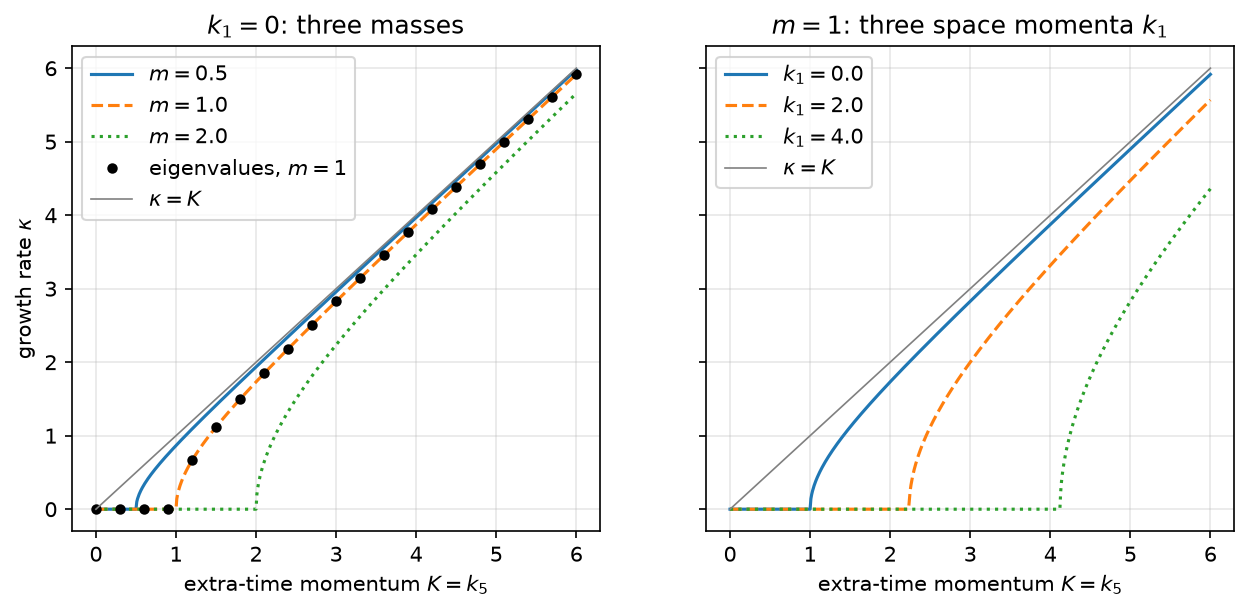

Figure 08a.1 saved as Revision/textbook/figures/08a_1_growth_rate_vs_momentum.png


In [6]:
def mode_matrix(mass, momenta):
    """h_k = -i m gamma^(x4) - gamma^(x4) sum_a k_a gamma^(xa); momenta: {a: k_a}."""
    g4n = GAMMA[3]
    result = -1j * mass * g4n.astype(complex)
    for a, k_a in momenta.items():
        result = result - k_a * (g4n @ GAMMA[a - 1])
    return result


def growth_rate(mass, K, k1=0.0):
    """kappa = sqrt(K^2 - m^2 - k1^2) where positive, else 0 (numpy arrays too)."""
    return np.sqrt(np.maximum(K**2 - mass**2 - k1**2, 0.0))


K_values = np.linspace(0.0, 6.0, 61)  # extra-time momenta 0, 0.1, ..., 6
numerical = np.array([np.max(np.linalg.eigvals(mode_matrix(1.0, {5: K})).imag)
                      for K in K_values])  # the largest growth rate, m = 1
deviation = np.abs(numerical - growth_rate(1.0, K_values))
at_threshold = np.abs(K_values - 1.0) < 1e-12  # K = m exactly, where h_k^2 = 0
check(np.max(deviation[~at_threshold]) < 1e-10 and np.max(deviation) < 1e-6,
      "growth rate from the eigenvalues = sqrt(K^2 - m^2) (m = 1)")
report("growth rate at m = 1, K = 2 (sqrt 3)", f"{growth_rate(1.0, 2.0):.9f}")
report("growth rate at m = 1, K = 1000", f"{growth_rate(1.0, 1000.0):.6f}")
check_record(growth_rate(1.0, 1000.0) > 999.0 and growth_rate(1.0, 1e6) > 999999.0,
             "the growth rate has no upper bound (kappa/K tends to 1)",
             "Revision/theory/reports/python-scope.json",
             "extra_time_growth_rates_unbounded", "which has no upper bound")

K_fine = np.linspace(0.0, 6.0, 601)
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.2), sharey=True)
for mass, style in ((0.5, "-"), (1.0, "--"), (2.0, ":")):
    left.plot(K_fine, growth_rate(mass, K_fine), style, label=f"$m = {mass}$")
left.plot(K_values[::3], numerical[::3], "o", markersize=4, color="black",
          label="eigenvalues, $m = 1$")
left.plot(K_fine, K_fine, color="gray", linewidth=0.8, label="$\\kappa = K$")
left.set_xlabel("extra-time momentum $K = k_5$")
left.set_ylabel("growth rate $\\kappa$")
left.set_title("$k_1 = 0$: three masses")
left.legend(loc="upper left")
for k1, style in ((0.0, "-"), (2.0, "--"), (4.0, ":")):
    right.plot(K_fine, growth_rate(1.0, K_fine, k1), style, label=f"$k_1 = {k1}$")
right.plot(K_fine, K_fine, color="gray", linewidth=0.8, label="$\\kappa = K$")
right.set_xlabel("extra-time momentum $K = k_5$")
right.set_title("$m = 1$: three space momenta $k_1$")
right.legend(loc="upper left")
save_figure(fig, "growth_rate_vs_momentum",
            "The growth rate $\\kappa = \\sqrt{K^2 - m^2 - k_1^2}$ of the growing "
            "waves against the momentum $K = k_5$ along the extra time $x_5$ "
            "(frozen coefficients); both axes in the same unit, an inverse length. "
            "Left: masses $m = 0.5, 1, 2$ with $k_1 = 0$, and the black dots are "
            "the largest imaginary parts of the computed eigenvalues of the mode "
            "matrix for $m = 1$. Right: $m = 1$ with space momenta $k_1 = 0, 2, 4$. "
            "Below the threshold $K^2 = m^2 + k_1^2$ the waves oscillate and "
            "$\\kappa = 0$; above it every curve approaches the gray line "
            "$\\kappa = K$, so the rate has no upper bound.")

## 10. Where the waves oscillate and where they grow

The next cell computes the growth rate on a grid of $201 \times 201$ points of the
plane of the space momentum $k_1$ and the extra-time momentum $k_5$ (with $m = 1$)
and draws it as a colour map. The white region is where $E^2 > 0$ (oscillation);
its border is the curve $k_5^2 - k_1^2 = 1$ (a hyperbola), and the contour lines
are the curves of equal growth rate $\kappa = 1, 2, 3, 4$.

RESULT fraction of the grid where the waves grow = 0.4439
PASS kappa = 0 at k = 0 and kappa = sqrt(24) at k1 = 0, k5 = 5


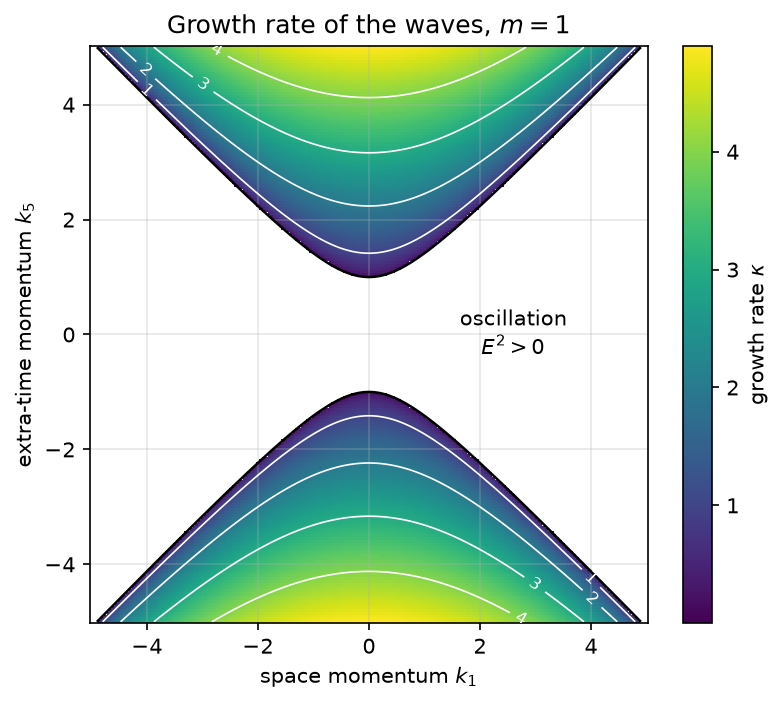

Figure 08a.2 saved as Revision/textbook/figures/08a_2_growth_map.png


In [7]:
k1_grid, k5_grid = np.meshgrid(np.linspace(-5.0, 5.0, 201), np.linspace(-5.0, 5.0, 201))
E2_grid = 1.0 + k1_grid**2 - k5_grid**2  # m = 1
kappa_grid = np.sqrt(np.maximum(-E2_grid, 0.0))
growing_fraction = float(np.mean(E2_grid < 0.0))
report("fraction of the grid where the waves grow", f"{growing_fraction:.4f}")
check(abs(kappa_grid[100, 100]) == 0.0 and abs(kappa_grid[200, 100] - 24**0.5) < 1e-12,
      "kappa = 0 at k = 0 and kappa = sqrt(24) at k1 = 0, k5 = 5")

fig, ax = plt.subplots(figsize=(6.0, 5.0))
shown = np.where(E2_grid < 0.0, kappa_grid, np.nan)  # nan: not coloured (white)
image = ax.pcolormesh(k1_grid, k5_grid, shown, cmap="viridis", shading="auto")
fig.colorbar(image, ax=ax, label="growth rate $\\kappa$")
lines = ax.contour(k1_grid, k5_grid, kappa_grid, levels=[1, 2, 3, 4], colors="white",
                   linewidths=0.8)
ax.clabel(lines, fmt="%d", fontsize=8)
ax.contour(k1_grid, k5_grid, E2_grid, levels=[0.0], colors="black", linewidths=1.2)
ax.text(2.6, 0.0, "oscillation\n$E^2 > 0$", ha="center", va="center")
ax.set_xlabel("space momentum $k_1$")
ax.set_ylabel("extra-time momentum $k_5$")
ax.set_title("Growth rate of the waves, $m = 1$")
save_figure(fig, "growth_map",
            "The growth rate $\\kappa$ in the plane of the space momentum $k_1$ "
            "(horizontal) and the extra-time momentum $k_5$ (vertical) for $m = 1$, "
            "both in the same unit, an inverse length; frozen coefficients. White: "
            "$E^2 = 1 + k_1^2 - k_5^2 > 0$, the waves oscillate. Coloured: the waves "
            "grow; the black curve $k_5^2 - k_1^2 = 1$ is the border, and the white "
            "contour lines mark $\\kappa = 1, 2, 3, 4$. The two coloured regions "
            "reach to infinity: however large $k_1$ is, a large enough $k_5$ "
            "makes the waves grow.")

## 11. Solving in time, in two independent ways

The equation in time is $i\,du/dx_4 = h_k u$. Because $h_k^2 = E^2 I_{16}$, the
exponential series of $e^{-ih_k x_4}$ collapses to
$u(x_4) = \big(\cos(Ex_4) I_{16} - i\,\frac{\sin(Ex_4)}{E}\,h_k\big)\,u(0)$:
the even powers of $h_k$ are powers of $E^2$ and give the cosine, the odd ones give
$h_k$ times the sine. For $E = i\kappa$ this is $\cosh(\kappa x_4) I_{16} -
i\,\frac{\sinh(\kappa x_4)}{\kappa}h_k$, and for $E = 0$ it is $I_{16} - i h_k x_4$
(the limit). The next cell implements this formula (`evolve`) and, independently,
the RK4 method with 3000 steps (`rk4`), starts both from the same random column
(fixed seed, so every run uses the same numbers) and compares them at $x_4 = 3$.

In [8]:
def evolve(hk, E2_value, x4, u0):
    """u(x4) = (cos(E x4) - i sin(E x4)/E h_k) u0, with E = sqrt(E^2) (complex)."""
    if E2_value == 0.0:
        return u0 - 1j * x4 * (hk @ u0)  # the limit E -> 0
    E = np.sqrt(complex(E2_value))  # E is imaginary when E^2 < 0
    return np.cos(E * x4) * u0 - 1j * np.sin(E * x4) / E * (hk @ u0)


def rk4(hk, x4_end, u0, steps):
    """The classical RK4 method for du/dx4 = -i h_k u from 0 to x4_end."""
    step = x4_end / steps
    u = u0.astype(complex)
    for _ in range(steps):
        s1 = -1j * (hk @ u)
        s2 = -1j * (hk @ (u + step / 2 * s1))
        s3 = -1j * (hk @ (u + step / 2 * s2))
        s4 = -1j * (hk @ (u + step * s3))
        u = u + step / 6 * (s1 + 2 * s2 + 2 * s3 + s4)
    return u


rng = np.random.default_rng(12345)  # fixed seed: the same numbers in every run
u_start = rng.normal(size=16) + 1j * rng.normal(size=16)
u_start = u_start / np.sqrt(np.vdot(u_start, u_start).real)  # u^dagger u = 1
worst = 0.0
for K in (0.5, 1.0, 2.0, 3.0):
    hk = mode_matrix(1.0, {5: K})
    exact = evolve(hk, 1.0 - K**2, 3.0, u_start)
    stepped = rk4(hk, 3.0, u_start, 3000)
    relative = np.linalg.norm(exact - stepped) / np.linalg.norm(exact)
    worst = max(worst, relative)
    say(f"K = {K}: u^dagger u at x4 = 3 is {np.vdot(exact, exact).real:.6e}")
check(worst < 1e-9, "the closed formula and RK4 agree at x4 = 3 (relative < 1e-9)")

K = 0.5: u^dagger u at x4 = 3 is 1.347676e+00
K = 1.0: u^dagger u at x4 = 3 is 2.006346e+01
K = 2.0: u^dagger u at x4 = 3 is 1.880098e+04
K = 3.0: u^dagger u at x4 = 3 is 1.086955e+07
PASS the closed formula and RK4 agree at x4 = 3 (relative < 1e-9)


The next cell draws $\ln(u^\dagger u)$ against $x_4$ for five extra-time momenta
($m = 1$). For $K < 1$ the size only oscillates; at $K = 1$ ($E = 0$) it grows like
a power of $x_4$; for $K > 1$ the curves become straight lines of slope $2\kappa$
(dashed), because $u^\dagger u$ grows like $e^{2\kappa x_4}$.

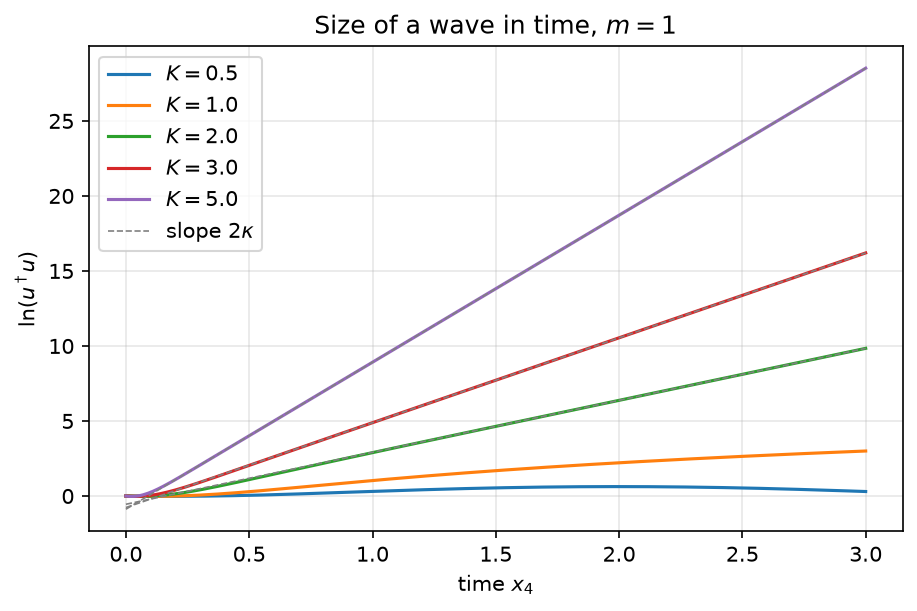

Figure 08a.3 saved as Revision/textbook/figures/08a_3_norm_in_time.png


In [9]:
x4_values = np.linspace(0.0, 3.0, 301)
fig, ax = plt.subplots()
for K in (0.5, 1.0, 2.0, 3.0, 5.0):
    hk = mode_matrix(1.0, {5: K})
    sizes = [np.vdot(v, v).real for v in
             (evolve(hk, 1.0 - K**2, x4, u_start) for x4 in x4_values)]
    ax.plot(x4_values, np.log(sizes), label=f"$K = {K}$")
    if K > 1.0:  # the asymptotic straight line of slope 2 kappa
        kappa = growth_rate(1.0, K)
        ax.plot(x4_values, np.log(sizes[-1]) + 2 * kappa * (x4_values - 3.0), "--",
                color="gray", linewidth=0.8)
# An empty line that only adds the dashed straight lines to the legend:
ax.plot([], [], "--", color="gray", linewidth=0.8, label="slope $2\\kappa$")
ax.set_xlabel("time $x_4$")
ax.set_ylabel("$\\ln(u^\\dagger u)$")
ax.set_title("Size of a wave in time, $m = 1$")
ax.legend();
save_figure(fig, "norm_in_time",
            "The natural logarithm of the size $u^\\dagger u$ of a wave against the "
            "time $x_4$ for $m = 1$ and five extra-time momenta $K$, all started from "
            "the same random column of size 1; time and momenta in units of the "
            "inverse of $m$ and of $m$. For $K = 0.5$ the size stays bounded; for "
            "$K = 1$ ($E = 0$) it grows like a power of $x_4$; for $K = 2, 3, 5$ it "
            "grows exponentially and the curves approach straight lines of slope "
            "$2\\kappa$ (gray dashed), $2\\sqrt3$, $2\\sqrt8$ and $2\\sqrt{24}$.")

## 12. Hadamard: no continuous dependence on the data

Take as data at $x_4 = 0$ one growing wave, $\epsilon\,e^{iKx_5}u_+$, where $u_+$
is an eigenvector of $h_k$ for $+i\kappa$ with $u_+^\dagger u_+ = 1$. Its Sobolev
size of order $s$ is $\epsilon(1 + K^2)^{s/2}$. At $x_4 = 1$ the solution is
$\epsilon\,e^{\kappa}e^{iKx_5}u_+$, of size $\epsilon\,e^{\kappa}$. The ratio
(size of the solution at $x_4 = 1$) / (size of the data) is therefore
$e^{\kappa(K)}(1 + K^2)^{-s/2}$, the same for every $\epsilon$. Because $\kappa(K)$
grows like $K$, the exponential beats every power: for every $s$ the ratio is
unbounded. So data as small as we like (in any Sobolev norm) can give solutions as
large as we like after one unit of time: the solution does not depend continuously
on the data. The next cell finds $u_+$ numerically, confirms that it grows exactly
like $e^{\kappa x_4}$, and draws $\log_{10}$ of the ratio for $s = 0, 2, 4, 8$.

PASS a growing eigenvector grows exactly like e^(kappa x4) (K = 4)
RESULT s = 0: first K (step 0.1) with ratio above 10^6 = 13.9
PASS s = 0: the ratio exceeds 10^50 at K = 200
RESULT s = 2: first K (step 0.1) with ratio above 10^6 = 19.9
PASS s = 2: the ratio exceeds 10^50 at K = 200
RESULT s = 4: first K (step 0.1) with ratio above 10^6 = 27.1
PASS s = 4: the ratio exceeds 10^50 at K = 200
RESULT s = 8: first K (step 0.1) with ratio above 10^6 = 44.2
PASS s = 8: the ratio exceeds 10^50 at K = 200


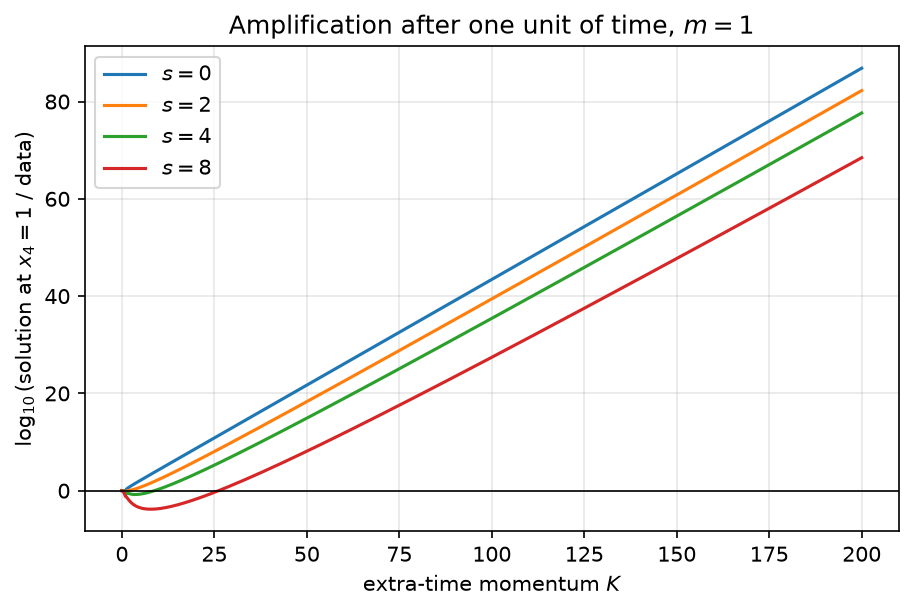

Figure 08a.4 saved as Revision/textbook/figures/08a_4_hadamard_ratio.png


In [10]:
def growing_eigenvector(mass, K):
    """A unit eigenvector of h_k (k5 = K) for the eigenvalue +i kappa."""
    hk = mode_matrix(mass, {5: K})
    kappa = growth_rate(mass, K)
    # The null space of h_k - i kappa I: the right singular vector of the smallest
    # singular value (numpy sorts the singular values from large to small).
    _, _, vh = np.linalg.svd(hk - 1j * kappa * np.eye(16))
    u_plus = vh[-1].conj()
    return hk, kappa, u_plus / np.linalg.norm(u_plus)


hk, kappa, u_plus = growing_eigenvector(1.0, 4.0)
later = evolve(hk, 1.0 - 4.0**2, 1.0, u_plus)
check(np.linalg.norm(hk @ u_plus - 1j * kappa * u_plus) < 1e-12
      and abs(np.linalg.norm(later) - np.exp(kappa)) < 1e-9 * np.exp(kappa),
      "a growing eigenvector grows exactly like e^(kappa x4) (K = 4)")

K_axis = np.linspace(0.0, 200.0, 2001)
fig, ax = plt.subplots()
for s in (0, 2, 4, 8):
    log_ratio = (growth_rate(1.0, K_axis) - s / 2 * np.log(1 + K_axis**2)) / np.log(10)
    ax.plot(K_axis, log_ratio, label=f"$s = {s}$")
    crossing = K_axis[np.argmax(log_ratio > 6.0)]  # first K with ratio above 10^6
    report(f"s = {s}: first K (step 0.1) with ratio above 10^6", f"{crossing:.1f}")
    check(log_ratio[-1] > 50.0, f"s = {s}: the ratio exceeds 10^50 at K = 200")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("extra-time momentum $K$")
ax.set_ylabel("$\\log_{10}$(solution at $x_4 = 1$ / data)")
ax.set_title("Amplification after one unit of time, $m = 1$")
ax.legend();
save_figure(fig, "hadamard_ratio",
            "The base-10 logarithm of the amplification, the size of the solution "
            "at $x_4 = 1$ divided by the size of the data at $x_4 = 0$, for one "
            "growing wave of extra-time momentum $K$ and $m = 1$, with the data "
            "measured in the Sobolev norm of order $s = 0, 2, 4, 8$; horizontal "
            "axis $K$ in units of $m$. The amplification is $e^{\\kappa}(1 + "
            "K^2)^{-s/2}$: a stronger norm only delays the rise, and every curve "
            "grows without bound, so arbitrarily small data give arbitrarily large "
            "solutions and the problem is not well posed in the sense of Hadamard.")

## 13. The Krein form is conserved; the growing waves have Krein form zero

From $B h_k = h_k^\dagger B$ (section 6): $\frac{d}{dx_4}(u^\dagger B u) = i\,u^\dagger
(h_k^\dagger B - B h_k)u = 0$, so the Krein form never changes, while
$\frac{d}{dx_4}(u^\dagger u) = i\,u^\dagger(h_k^\dagger - h_k)u$ is not zero when
$h_k$ is not Hermitian. The next cell follows a random wave with $m = 1$, $K = 2$
up to $x_4 = 4$ and compares both, then checks two exact statements of the pairing
record on its samples: the eight-dimensional eigenspace of a growing frequency
($m = 1$, $k_5 = 2$) carries the Krein form zero (every $u^\dagger B v$ vanishes on
it), while an eigenspace of a real frequency ($m = 1$, $k_1 = 2$, $k_8 = 2$, $E = 3$)
carries a Krein form with four positive and four negative directions (*inertia*
(4, 4)). Both checks compare the dimensions and the inertia found here with the
text of the pairing record (which calls the frequency $w$).

RESULT Krein form at x4 = 0 = +0.129919115
RESULT u^dagger u at x4 = 4 = 6.006621e+05
PASS the Krein form u^dagger B u is constant (drift / max(u^dagger u, 1) < 1e-12)
PASS m = 1, k5 = 2: the 8-dim eigenspace of +i sqrt(3) is Krein-neutral
     reproduces Revision/pairing/reports/python-pairing.json, check
    Q.one_particle_complex_frequency_Krein_neutral
RESULT Krein inertia of the eigenspace of E = 3 (m = 1, k1 = k8 = 2) = (4, 4)
PASS m = 1, k1 = k8 = 2: the eigenspace of E = 3 has Krein inertia (4, 4)
     reproduces Revision/pairing/reports/python-pairing.json, check
    Q.one_particle_Krein_inertia


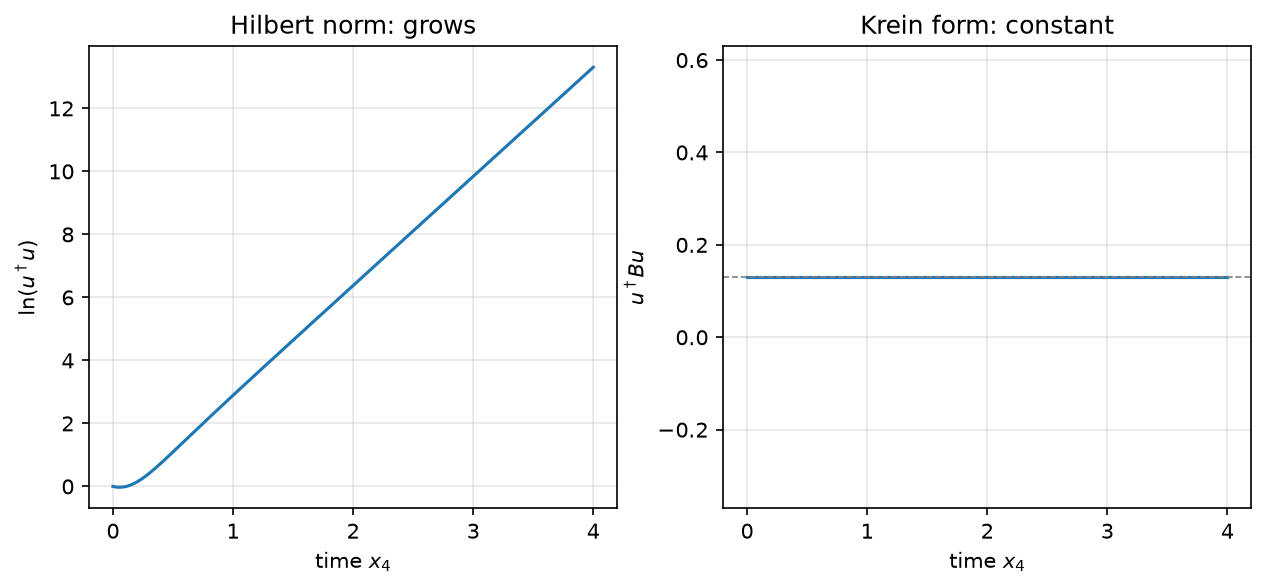

Figure 08a.5 saved as Revision/textbook/figures/08a_5_krein_norm.png


In [11]:
hk = mode_matrix(1.0, {5: 2.0})
times = np.linspace(0.0, 4.0, 401)
path = [evolve(hk, 1.0 - 4.0, x4, u_start) for x4 in times]
hilbert = np.array([np.vdot(v, v).real for v in path])  # u^dagger u
krein_values = np.array([np.vdot(v, B @ v) for v in path])  # u^dagger B u
drift = np.max(np.abs(krein_values - krein_values[0]) / np.maximum(hilbert, 1.0))
report("Krein form at x4 = 0", f"{krein_values[0].real:+.9f}")
report("u^dagger u at x4 = 4", f"{hilbert[-1]:.6e}")
imaginary = np.max(np.abs(krein_values.imag) / np.maximum(hilbert, 1.0))
check(drift < 1e-12 and imaginary < 1e-12,
      "the Krein form u^dagger B u is constant (drift / max(u^dagger u, 1) < 1e-12)")


def eigenspace(hk, value):
    """An orthonormal basis (columns) of the eigenspace of hk for value."""
    _, singular, vh = np.linalg.svd(hk - value * np.eye(16))
    return vh[singular < 1e-9].conj().T


V_grow = eigenspace(mode_matrix(1.0, {5: 2.0}), 1j * 3**0.5)
form_grow = V_grow.conj().T @ B @ V_grow  # the Krein form on that eigenspace
check_record(V_grow.shape[1] == 8 and np.max(np.abs(form_grow)) < 1e-12,
             "m = 1, k5 = 2: the 8-dim eigenspace of +i sqrt(3) is Krein-neutral",
             "Revision/pairing/reports/python-pairing.json",
             "Q.one_particle_complex_frequency_Krein_neutral",
             "(0, 0, 0, 2, 0, 0, 0): w^2 = -3, eigenspace dimensions "
             f"[{V_grow.shape[1]}, {V_grow.shape[1]}], B-form identically zero: True")
V_real = eigenspace(mode_matrix(1.0, {1: 2.0, 8: 2.0}), 3.0)
form_real = np.linalg.eigvalsh(V_real.conj().T @ B @ V_real)  # Hermitian 8 x 8
inertia = (int(np.sum(form_real > 1e-9)), int(np.sum(form_real < -1e-9)))
report("Krein inertia of the eigenspace of E = 3 (m = 1, k1 = k8 = 2)", inertia)
check_record(V_real.shape[1] == 8 and inertia == (4, 4),
             "m = 1, k1 = k8 = 2: the eigenspace of E = 3 has Krein inertia (4, 4)",
             "Revision/pairing/reports/python-pairing.json",
             "Q.one_particle_Krein_inertia",
             f"w = 3: dim {V_real.shape[1]}, Krein inertia ({inertia[0]},{inertia[1]})")

fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0))
left.plot(times, np.log(hilbert))
left.set_xlabel("time $x_4$")
left.set_ylabel("$\\ln(u^\\dagger u)$")
left.set_title("Hilbert norm: grows")
right.plot(times, krein_values.real)
right.axhline(krein_values[0].real, color="gray", linestyle="--", linewidth=0.8)
right.set_ylim(krein_values[0].real - 0.5, krein_values[0].real + 0.5)
right.set_xlabel("time $x_4$")
right.set_ylabel("$u^\\dagger B u$")
right.set_title("Krein form: constant")
save_figure(fig, "krein_norm",
            "One wave with $m = 1$ and extra-time momentum $K = 2$ followed from "
            "$x_4 = 0$ to $x_4 = 4$ (time in units of $1/m$). Left: the natural "
            "logarithm of its Hilbert norm $u^\\dagger u$, which grows like "
            "$e^{2\\sqrt3\\,x_4}$. Right: its Krein form $u^\\dagger B u$, which "
            "stays exactly at its starting value (gray dashed line). The growth "
            "is possible because the growing waves have Krein form zero: the "
            "positive and the negative parts of the Krein form grow together.")

## 14. The good sector: every frequency is real

In the good sector ($k_5 = k_6 = k_7 = 0$) $h_k$ is Hermitian (section 7), so its
eigenvalues are real. The next cell checks this for a random good-sector momentum,
checks that $B$ commutes with $h_k$ there, and then follows the eigenvalues
$\pm\sqrt{1 + k_1^2 - K^2}$ in the complex plane along two paths: a growing space
momentum $k_1$ from 0 to 2.5 (good sector) and a growing extra-time momentum $K$
from 0 to 2.5. Along the first path the eigenvalues move outwards on the real axis;
along the second they meet at 0 when $K = 1$ and then leave the real axis.

PASS good sector: h_k Hermitian, [B, h_k] = 0, eigenvalues real +-E
     reproduces Revision/theory/reports/python-field-theory.json, check
    good_sector_spectrum_and_B_sectors


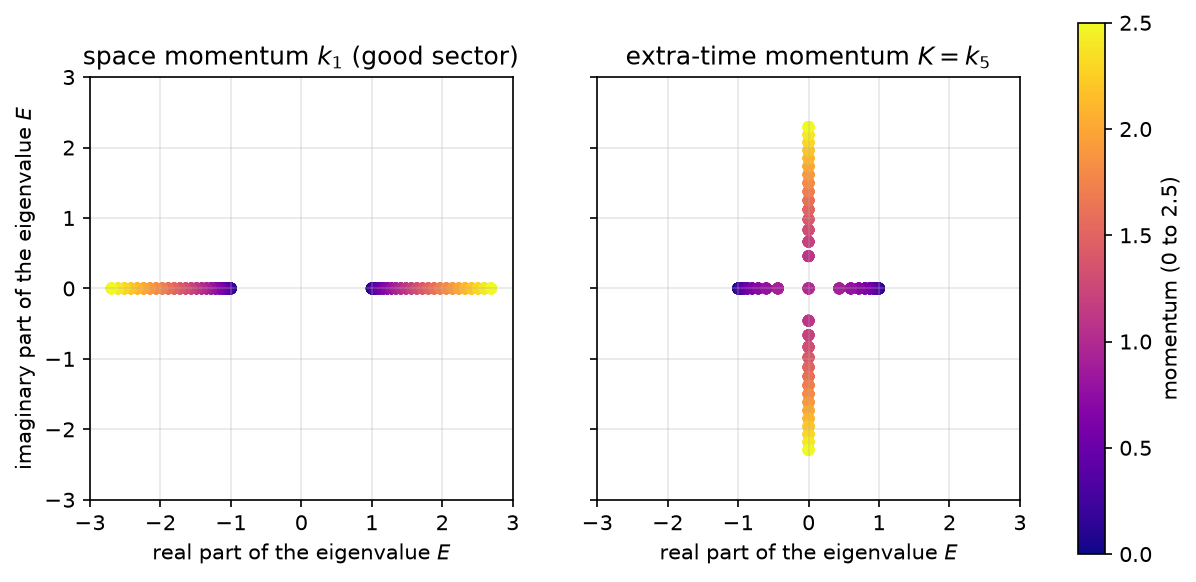

Figure 08a.6 saved as Revision/textbook/figures/08a_6_eigenvalue_paths.png


In [12]:
good = mode_matrix(1.3, {1: 0.4, 2: -1.1, 3: 0.7, 8: 2.2})  # no k5, k6, k7
good_eigenvalues = np.linalg.eigvals(good)
E_good = np.sqrt(1.3**2 + 0.4**2 + 1.1**2 + 0.7**2 + 2.2**2)
check_record(np.allclose(good, good.conj().T) and np.allclose(good @ B, B @ good)
             and np.max(np.abs(np.abs(good_eigenvalues) - E_good)) < 1e-12
             and np.max(np.abs(good_eigenvalues.imag)) < 1e-12,
             "good sector: h_k Hermitian, [B, h_k] = 0, eigenvalues real +-E",
             "Revision/theory/reports/python-field-theory.json",
             "good_sector_spectrum_and_B_sectors", "h is Hermitian", "[B, h] = 0")

path_values = np.linspace(0.0, 2.5, 26)  # the momenta 0, 0.1, ..., 2.5
colours = np.repeat(path_values, 16)  # each matrix has 16 eigenvalues
fig, panels = plt.subplots(1, 2, figsize=(10.0, 4.6), sharey=True)
for panel, direction, name in ((panels[0], 1, "space momentum $k_1$ (good sector)"),
                               (panels[1], 5, "extra-time momentum $K = k_5$")):
    points = np.concatenate([np.linalg.eigvals(mode_matrix(1.0, {direction: p}))
                             for p in path_values])
    dots = panel.scatter(points.real, points.imag, c=colours, cmap="plasma", s=22)
    panel.set_xlim(-3.0, 3.0)
    panel.set_ylim(-3.0, 3.0)
    panel.set_aspect("equal")
    panel.set_xlabel("real part of the eigenvalue $E$")
    panel.set_title(name)
panels[0].set_ylabel("imaginary part of the eigenvalue $E$")
fig.colorbar(dots, ax=panels, label="momentum (0 to 2.5)")
save_figure(fig, "eigenvalue_paths",
            "The eigenvalues $E$ of the mode matrix for $m = 1$ in the complex "
            "plane (horizontal: real part, vertical: imaginary part, in units of "
            "$m$), coloured by the momentum from 0 (dark) to 2.5 (bright). Left: a "
            "growing space momentum $k_1$ (good sector); the eigenvalues "
            "$\\pm\\sqrt{1 + k_1^2}$ move outwards along the real axis and stay "
            "real. Right: a growing extra-time momentum $K$; the eigenvalues "
            "$\\pm\\sqrt{1 - K^2}$ move inwards, meet at 0 for $K = 1$ and then "
            "leave along the imaginary axis as $\\pm i\\sqrt{K^2 - 1}$: growth.")

## 15. The last check

The last cell checks that the six figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [13]:
for name in ("08a_1_growth_rate_vs_momentum.png", "08a_2_growth_map.png",
             "08a_3_norm_in_time.png", "08a_4_hadamard_ratio.png",
             "08a_5_krein_norm.png", "08a_6_eigenvalue_paths.png"):
    check(output_file(f"{FIGURE_FOLDER}/{name}").is_file(),
          f"the figure file {name} exists")
all_checks_passed()

PASS the figure file 08a_1_growth_rate_vs_momentum.png exists
PASS the figure file 08a_2_growth_map.png exists
PASS the figure file 08a_3_norm_in_time.png exists
PASS the figure file 08a_4_hadamard_ratio.png exists
PASS the figure file 08a_5_krein_norm.png exists
PASS the figure file 08a_6_eigenvalue_paths.png exists
ALL 30 CHECKS PASSED (notebook 08a)


## 16. What this notebook showed

- With the author's gamma matrices the mode matrix of a plane wave (frozen
  coefficients) satisfies $h_k^2 = E^2 I_{16}$ exactly, with
  $E^2 = m^2 + k_1^2 + k_2^2 + k_3^2 + k_8^2 - k_5^2 - k_6^2 - k_7^2$ (PROVED, exact
  sympy; Revision check `extra_time_growth_rates_unbounded`).
- $h_k$ is Hermitian exactly when there is no extra-time momentum; in the good
  sector every frequency is real (PROVED).
- With enough extra-time momentum the frequencies are $\pm i\kappa$ and half of the
  waves grow like $e^{\kappa x_4}$; for $m = 1$, $k_5 = 2$ the rate is $\sqrt3$
  (PROVED; check `extra_time_modes_grow`).
- The growth rate $\kappa = \sqrt{K^2 - m^2 - k_1^2 - \dots}$ has no upper bound
  (PROVED). The amplification $e^{\kappa}(1 + K^2)^{-s/2}$ after one unit of time is
  unbounded in every Sobolev norm, so the initial-value problem for data that
  depend on the extra times is NOT well posed in the sense of Hadamard, although
  the slices $x_4 = $ const are non-characteristic (the equation can be solved for
  $\partial_4\Psi$).
- The Krein form $u^\dagger B u$ is conserved by every wave, also by the growing
  ones; the growing eigenspaces are Krein-neutral and the real-frequency ones have
  inertia (4, 4) (PROVED in the pairing record; reproduced here on its samples).
- Scope: these are statements with frozen coefficients (or in flat 4 + 4 space). In
  the author's metric the extra times deflate, so the frame momentum of a wave
  along an extra time grows with time; that is the subject of the next example of
  this chapter (Notebook 08b).